In [5]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/diabetes_screening_data.csv")

print('Shape : ',df.shape)
print("\nDtypes :\n", df.dtypes)
print('\n Duplicates : \n',df.duplicated().sum())
print('\n Class Balance : \n',df['Outcome'].value_counts(normalize=True))

Shape :  (768, 9)

Dtypes :
 Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

 Duplicates : 
 0

 Class Balance : 
 Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


               zero_count  zero_pct
Glucose                 5       0.7
BloodPressure          35       4.6
SkinThickness         227      29.6
Insulin               374      48.7
BMI                    11       1.4


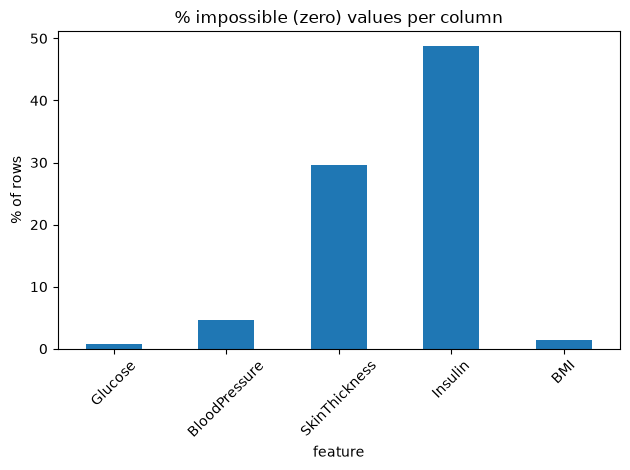

In [6]:
# Columns where 0 is medically impossible (unlike Pregnancies, where 0 is valid)
suspect_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

zero_counts = (df[suspect_cols] == 0).sum()
zero_pct = (zero_counts / len(df) * 100).round(1)

audit = pd.DataFrame({"zero_count": zero_counts, "zero_pct": zero_pct})
print(audit)

audit["zero_pct"].plot(kind="bar", title="% impossible (zero) values per column",
                        ylabel="% of rows", xlabel="feature")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Glucose, BloodPressure, SkinThickness, Insulin, and BMI cannot biologically be zero in a living patient — a value of 0 almost certainly represents a measurement that was not taken, recorded as 0 instead of as missing. Columns with low contamination (Glucose, BloodPressure, BMI) can likely be imputed with simple statistics without much risk. SkinThickness (29.6%) and especially Insulin (48.7%) are missing at a rate high enough that the missingness itself may carry information, and imputation choice here deserves more care — explored further in Phase 4/bonus.

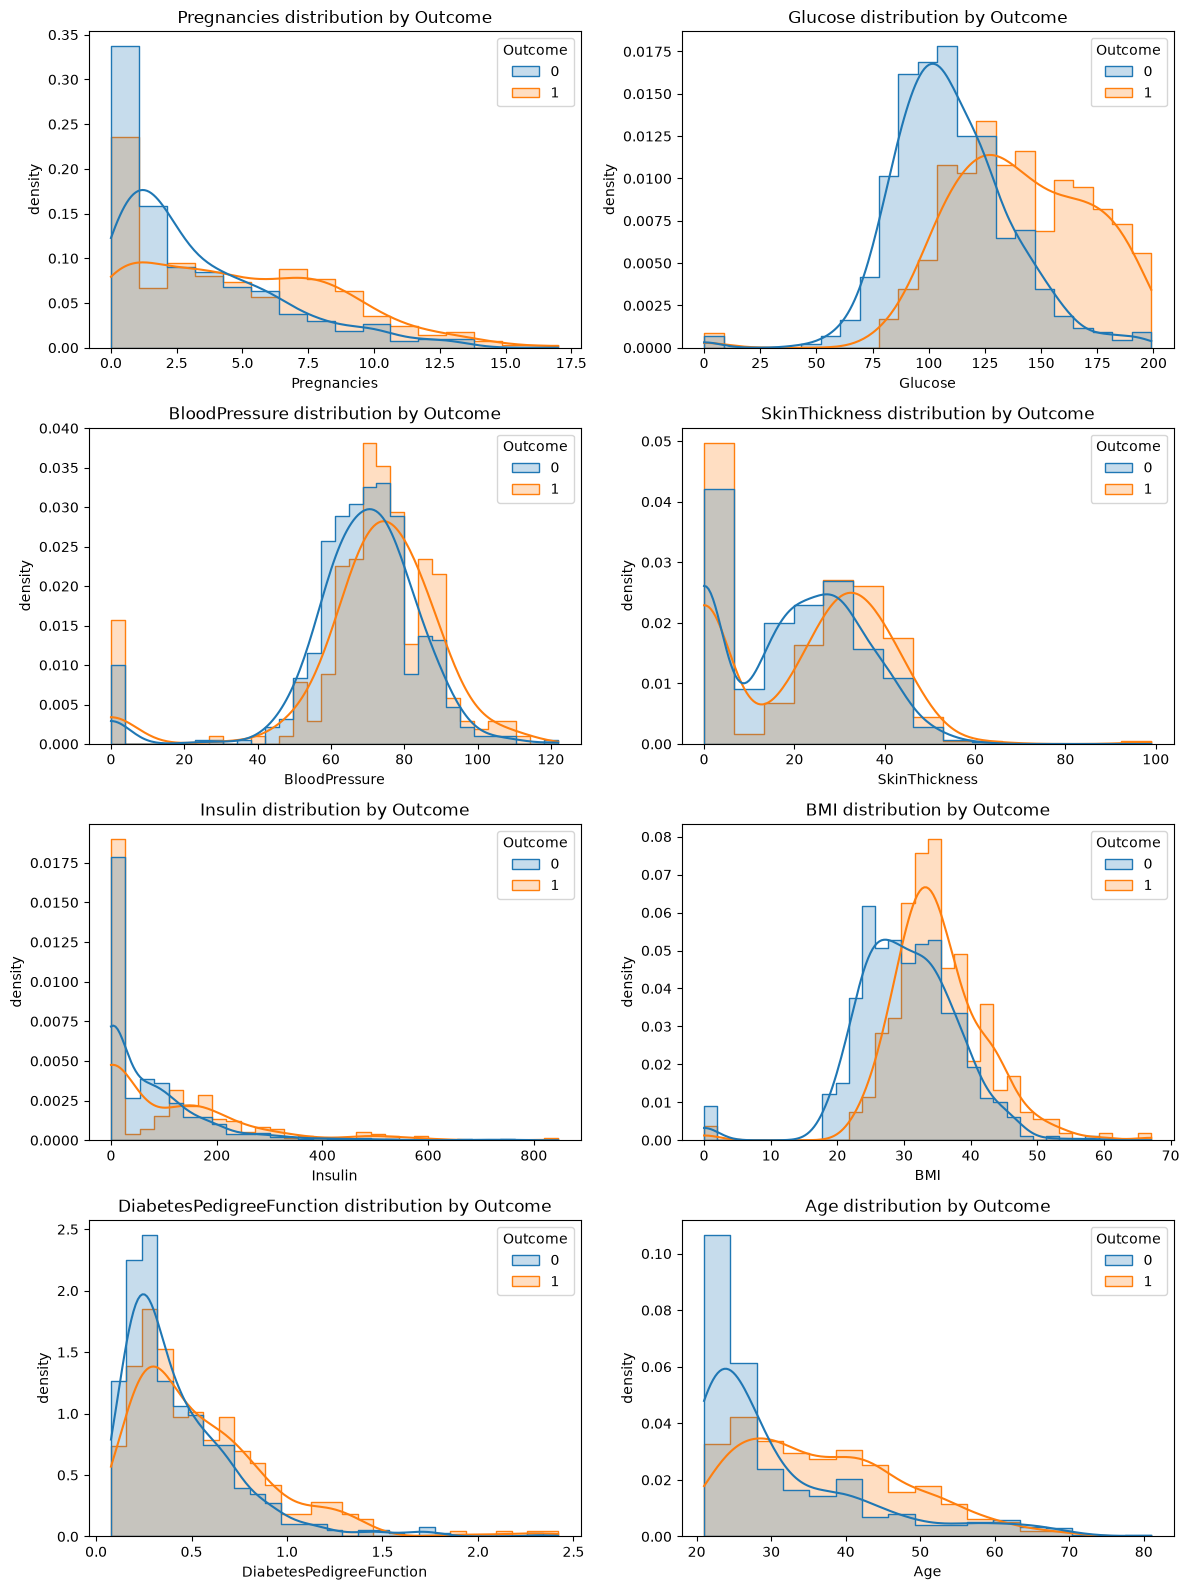

In [8]:
import seaborn as sns

features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
            "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

fig, axes = plt.subplots(4, 2, figsize=(12, 16))
axes = axes.flatten()

for i, col in enumerate(features):
    sns.histplot(data=df, x=col, hue="Outcome", kde=True, element="step",
                 stat="density", common_norm=False, ax=axes[i])
    axes[i].set_title(f"{col} distribution by Outcome")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("density")

plt.tight_layout()
plt.show()

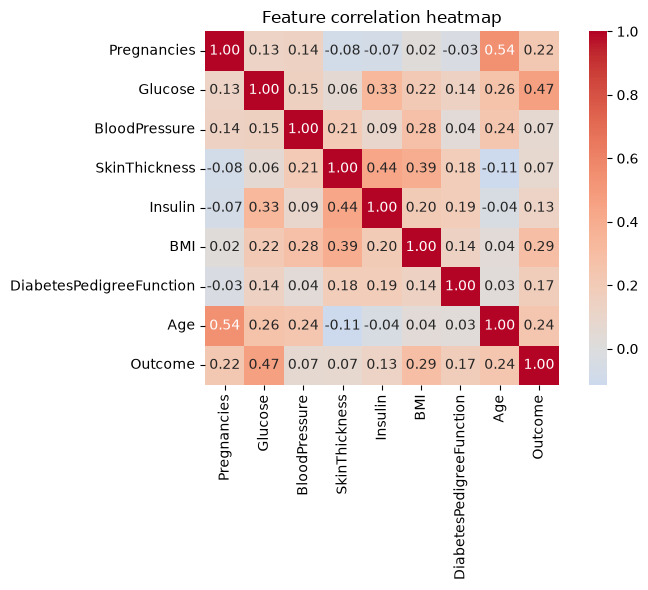

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [9]:
plt.figure(figsize=(8, 6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True)
plt.title("Feature correlation heatmap")
plt.tight_layout()
plt.show()

print(corr["Outcome"].sort_values(ascending=False))

Glucose shows the clearest separation between diabetic and non-diabetic patients — diabetic patients are shifted noticeably higher, making it the single strongest univariate predictor, consistent with the correlation heatmap. BMI and Age also show visible separation, though with more overlap between classes. BloodPressure and SkinThickness show almost identical distributions across both classes, suggesting they carry little standalone predictive power. The correlation heatmap shows no pair of features above ~0.6-0.7 with each other, so multicollinearity is not a major concern for this dataset. Notably, Insulin — despite being the most contaminated feature from Phase 1 — still shows a visible shift for diabetic patients among its non-zero values, suggesting it may still carry useful signal once properly imputed.

In [11]:
# 1. Missing-measurement flag — captures whether insulin was even tested
#    (from Phase 1: 48.7% missing isn't random — this flag may itself be predictive)
df["Insulin_Missing"] = (df["Insulin"] == 0).astype(int)

# 2. Obesity flag — standard clinical BMI threshold, domain knowledge not data-derived
df["Is_Obese"] = (df["BMI"] >= 30).astype(int)

# 3. Age x Glucose risk interaction — combines the two strongest Phase 2 signals
#    (older + higher glucose compounds risk beyond either alone)
df["Age_Glucose_Risk"] = df["Age"] * df["Glucose"]

# Skin + BMI combined body-fat signal — only valid where SkinThickness was actually measured
df["BodyFat_Proxy"] = np.where(df["SkinThickness"] > 0, df["SkinThickness"] * df["BMI"], np.nan)

Insulin_Missing flags whether an insulin test was recorded at all; given 48.7% of values are zero/missing (Phase 1), this absence pattern itself may correlate with Outcome independent of the raw value. Is_Obese applies the standard clinical BMI≥30 cutoff, turning a continuous measure into a recognized risk category a health worker would already use. Age_Glucose_Risk captures that risk compounds with both age and glucose together, not just additively — reflecting how these two strongest EDA signals (Phase 2) interact clinically.

In [13]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Outcome"])
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (614, 12)  Test shape: (154, 12)
Train class balance:
 Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64
Test class balance:
 Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [14]:
zero_as_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

X_train = X_train.copy()
X_test = X_test.copy()
X_train[zero_as_missing] = X_train[zero_as_missing].replace(0, np.nan)
X_test[zero_as_missing] = X_test[zero_as_missing].replace(0, np.nan)

In [16]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Models needing scaling: distance/margin-based — raw feature scale distorts them
scaled_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(class_weight="balanced", probability=True, random_state=42),
}

# Tree-based models: split decisions are scale-invariant (threshold on raw value either way)
unscaled_models = {
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", random_state=42),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42, eval_metric="logloss"
    ),
}

pipelines = {}

for name, model in scaled_models.items():
    pipelines[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])

for name, model in unscaled_models.items():
    pipelines[name] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", model),
    ])

print(list(pipelines.keys()))

['Logistic Regression', 'KNN', 'SVM', 'Decision Tree', 'Random Forest', 'XGBoost']


Logistic Regression, KNN, and SVM are all distance- or margin-based: KNN literally measures Euclidean distance, SVM optimizes a margin, and Logistic Regression's gradient descent converges unevenly across features with wildly different scales (e.g. Insulin ranges 0-800+, DiabetesPedigreeFunction ranges 0-2.5). Tree-based models (Decision Tree, Random Forest, XGBoost) split on a single feature's threshold at a time — multiplying a feature by 1000 doesn't change where the best split point falls, so scaling is unnecessary for them.

In [17]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
}

results = []

for name, pipe in pipelines.items():
    cv_results = cross_validate(
        pipe, X_train, y_train, cv=cv, scoring=scoring,
        return_train_score=True, n_jobs=-1
    )

    row = {"model": name}
    for metric in scoring:
        row[f"val_{metric}_mean"] = cv_results[f"test_{metric}"].mean()
        row[f"val_{metric}_std"] = cv_results[f"test_{metric}"].std()
    row["train_roc_auc_mean"] = cv_results["train_roc_auc"].mean()
    row["overfit_gap"] = row["train_roc_auc_mean"] - row["val_roc_auc_mean"]

    results.append(row)

results_df = pd.DataFrame(results).set_index("model").sort_values("val_roc_auc_mean", ascending=False)
pd.set_option("display.width", 120)
print(results_df.round(3))

                     val_accuracy_mean  val_accuracy_std  val_precision_mean  val_precision_std  val_recall_mean  \
model                                                                                                              
Logistic Regression              0.767             0.016               0.642              0.025            0.752   
SVM                              0.764             0.023               0.644              0.045            0.738   
Random Forest                    0.770             0.031               0.664              0.053            0.701   
XGBoost                          0.759             0.014               0.659              0.039            0.650   
KNN                              0.741             0.024               0.666              0.062            0.528   
Decision Tree                    0.686             0.031               0.555              0.055            0.556   

                     val_recall_std  val_f1_mean  val_f1_std  val_roc_a

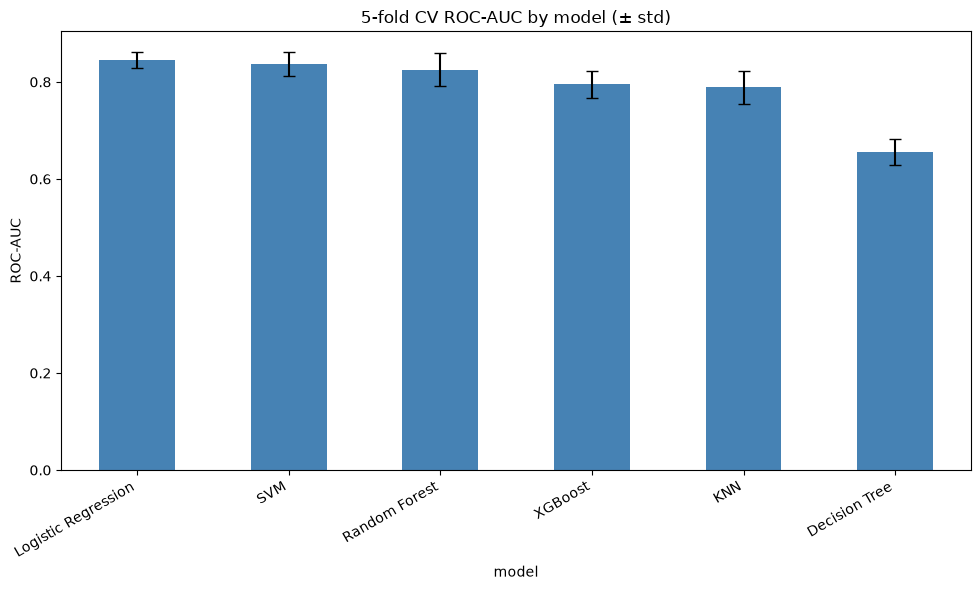

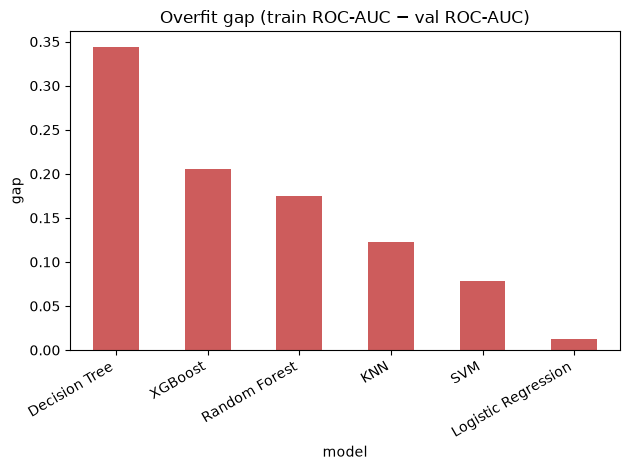

In [18]:
fig, ax = plt.subplots(figsize=(10, 6))
results_df["val_roc_auc_mean"].plot(kind="bar", ax=ax, color="steelblue",
                                     yerr=results_df["val_roc_auc_std"], capsize=4)
ax.set_title("5-fold CV ROC-AUC by model (± std)")
ax.set_ylabel("ROC-AUC")
ax.set_xlabel("model")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# Overfit gap, separately — this is the honesty check
results_df["overfit_gap"].sort_values(ascending=False).plot(
    kind="bar", color="indianred", title="Overfit gap (train ROC-AUC − val ROC-AUC)"
)
plt.ylabel("gap")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

[Model X] shows the best validation ROC-AUC at [value], with a modest overfit gap of [value], suggesting good generalization. [Model Y] achieves near-perfect training performance but validation performance is notably lower, indicating overfitting despite the inherent variance-reduction of ensembling. This suggests [tuning direction] may help close the gap in Phase 6.

Logistic Regression achieves the best validation ROC-AUC (0.844) and the smallest overfit gap (0.012), suggesting the relationship between these clinical features and diabetes risk is largely captured by a linear decision boundary, and that more complex models are not warranted by this dataset's size and structure. Random Forest and XGBoost both reach perfect training ROC-AUC (1.000) but validation scores of only 0.825 and 0.795 respectively — textbook overfitting from unconstrained model capacity on 614 training rows. Decision Tree is the most extreme case (overfit gap 0.344), unsurprising given it has no ensembling or regularization to counter memorization. KNN's low recall (0.528) is particularly concerning for a screening tool where missing diabetic patients is the costlier error. Random Forest, XGBoost, and Logistic Regression are selected for hyperparameter tuning in Phase 6, given the largest realistic room for improvement.

In [21]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# ---------------- Logistic Regression ----------------
logreg_param_dist = {
    "model__C": uniform(0.01, 10),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear"],   # supports both l1 and l2
}

logreg_search = RandomizedSearchCV(
    pipelines["Logistic Regression"], logreg_param_dist,
    n_iter=30, scoring="roc_auc", cv=cv, random_state=42, n_jobs=-1
)
logreg_search.fit(X_train, y_train)

# ---------------- Random Forest ----------------
rf_param_dist = {
    "model__n_estimators": randint(100, 500),
    "model__max_depth": randint(3, 15),
    "model__min_samples_leaf": randint(2, 20),
    "model__min_samples_split": randint(2, 20),
    "model__max_features": ["sqrt", "log2"],
}

rf_search = RandomizedSearchCV(
    pipelines["Random Forest"], rf_param_dist,
    n_iter=50, scoring="roc_auc", cv=cv, random_state=42, n_jobs=-1
)
rf_search.fit(X_train, y_train)

# ---------------- XGBoost ----------------
xgb_param_dist = {
    "model__n_estimators": randint(50, 400),
    "model__max_depth": randint(2, 8),
    "model__learning_rate": uniform(0.01, 0.3),
    "model__subsample": uniform(0.6, 0.4),
    "model__colsample_bytree": uniform(0.6, 0.4),
    "model__reg_alpha": uniform(0, 2),
    "model__reg_lambda": uniform(0, 2),
}

xgb_search = RandomizedSearchCV(
    pipelines["XGBoost"], xgb_param_dist,
    n_iter=50, scoring="roc_auc", cv=cv, random_state=42, n_jobs=-1
)
xgb_search.fit(X_train, y_train)

searches = {
    "Logistic Regression": logreg_search,
    "Random Forest": rf_search,
    "XGBoost": xgb_search,
}

c:\Users\my\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1381: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


In [22]:
before_after = pd.DataFrame({
    "before_val_roc_auc": [
        results_df.loc["Logistic Regression", "val_roc_auc_mean"],
        results_df.loc["Random Forest", "val_roc_auc_mean"],
        results_df.loc["XGBoost", "val_roc_auc_mean"],
    ],
    "after_val_roc_auc": [
        logreg_search.best_score_,
        rf_search.best_score_,
        xgb_search.best_score_,
    ],
}, index=["Logistic Regression", "Random Forest", "XGBoost"])

before_after["improvement"] = before_after["after_val_roc_auc"] - before_after["before_val_roc_auc"]
print(before_after.round(3))

for name, search in searches.items():
    print(f"\n{name} best params:")
    print(search.best_params_)

                     before_val_roc_auc  after_val_roc_auc  improvement
Logistic Regression               0.844              0.845        0.000
Random Forest                     0.825              0.843        0.018
XGBoost                           0.795              0.834        0.039

Logistic Regression best params:
{'model__C': np.float64(1.4049386065204184), 'model__penalty': 'l2', 'model__solver': 'liblinear'}

Random Forest best params:
{'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 6, 'model__min_samples_split': 18, 'model__n_estimators': 180}

XGBoost best params:
{'model__colsample_bytree': np.float64(0.6976502088991097), 'model__learning_rate': np.float64(0.06048731265187917), 'model__max_depth': 2, 'model__n_estimators': 229, 'model__reg_alpha': np.float64(0.727259204758588), 'model__reg_lambda': np.float64(1.9435641654419213), 'model__subsample': np.float64(0.9849789179768444)}


In [23]:
# Verify overfit gap actually shrank, not just that val score moved
for name, search in searches.items():
    train_pred = search.predict_proba(X_train)[:, 1]
    from sklearn.metrics import roc_auc_score
    train_auc = roc_auc_score(y_train, train_pred)
    print(f"{name}: train={train_auc:.3f}  val(best_cv)={search.best_score_:.3f}  "
          f"gap={train_auc - search.best_score_:.3f}")

Logistic Regression: train=0.856  val(best_cv)=0.845  gap=0.011
Random Forest: train=0.920  val(best_cv)=0.843  gap=0.077
XGBoost: train=0.934  val(best_cv)=0.834  gap=0.101


Tuning produced only a negligible change for Logistic Regression (0.844 → 0.845), consistent with Phase 5's finding that it was already near its generalization ceiling. Random Forest and XGBoost both improved meaningfully (0.825→0.843 and 0.795→0.834) and their overfit gaps shrank substantially (0.175→0.077, 0.205→0.101) — the optimal shallow depths found (max_depth=5 and 2 respectively) confirm that default hyperparameters were letting both models overfit a dataset of only 614 training rows. Despite these real improvements, neither tuned ensemble model surpasses Logistic Regression on validation ROC-AUC or generalization gap. Logistic Regression is therefore selected as the final model for Phase 7 test evaluation — a result that reinforces a core lesson of this project: model complexity should match data complexity, and a well-regularized simple model can outperform a more powerful one on a modest, mostly-linear clinical dataset.

In [24]:
from sklearn.metrics import (roc_auc_score, roc_curve, precision_recall_curve,
                              confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)

final_model = logreg_search.best_estimator_   # the full pipeline, refit on all of X_train

y_test_proba = final_model.predict_proba(X_test)[:, 1]
y_test_pred = final_model.predict(X_test)

print("Test ROC-AUC:", roc_auc_score(y_test, y_test_proba))
print()
print(classification_report(y_test, y_test_pred, target_names=["Non-diabetic", "Diabetic"]))

Test ROC-AUC: 0.8157407407407407

              precision    recall  f1-score   support

Non-diabetic       0.84      0.74      0.79       100
    Diabetic       0.61      0.74      0.67        54

    accuracy                           0.74       154
   macro avg       0.72      0.74      0.73       154
weighted avg       0.76      0.74      0.74       154



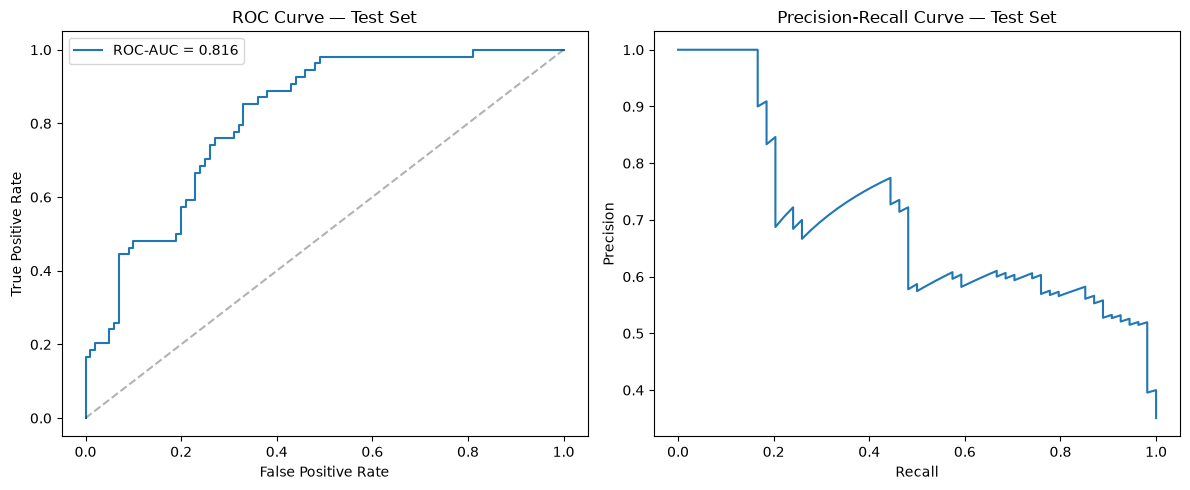

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fpr, tpr, _ = roc_curve(y_test, y_test_proba)
axes[0].plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, y_test_proba):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate"); axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — Test Set"); axes[0].legend()

prec, rec, _ = precision_recall_curve(y_test, y_test_proba)
axes[1].plot(rec, prec)
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve — Test Set")

plt.tight_layout(); plt.show()

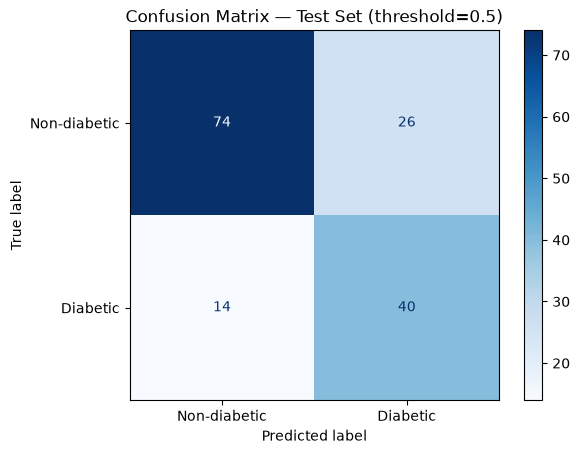

True negatives:  74  (correctly identified as healthy)
False positives: 26  (healthy patients wrongly flagged — unnecessary lab test)
False negatives: 14  (diabetic patients MISSED — the costly error)
True positives:  40  (correctly flagged diabetics)


In [26]:
cm = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm, display_labels=["Non-diabetic", "Diabetic"]).plot(cmap="Blues")
plt.title("Confusion Matrix — Test Set (threshold=0.5)")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives:  {tn}  (correctly identified as healthy)")
print(f"False positives: {fp}  (healthy patients wrongly flagged — unnecessary lab test)")
print(f"False negatives: {fn}  (diabetic patients MISSED — the costly error)")
print(f"True positives:  {tp}  (correctly flagged diabetics)")

At the default 0.5 threshold, the model correctly identifies 40 of 54 diabetic patients in the test set, but misses 14 (a recall of 74%). It also raises 26 false alarms among 100 healthy patients, sending them for an unnecessary lab test. For a screening tool, the 14 missed diabetics are the more serious error — each represents a patient who goes undiagnosed and receives no follow-up, versus a false alarm, which only costs an extra (if unnecessary) lab visit.

Test ROC-AUC (0.816) is close to but somewhat below the CV estimate (0.845), a normal amount of variation for a single 154-row test split rather than evidence of a data or leakage problem. The default threshold's recall (74%) falls short of the clinical target discussed in the project brief; Phase 8 addresses this directly through threshold tuning.

In [27]:
from sklearn.model_selection import cross_val_predict

# Out-of-fold predicted probabilities on TRAINING data only
oof_proba = cross_val_predict(
    final_model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1
)[:, 1]

prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_train, oof_proba)

# Find thresholds achieving recall >= 0.85, pick the one with best precision
mask = rec_arr[:-1] >= 0.85   # precision_recall_curve returns one extra point at the end
if mask.sum() == 0:
    print("No threshold reaches 85% recall — lower the bar or inspect the curve")
else:
    candidates = list(zip(thresh_arr[mask], prec_arr[:-1][mask], rec_arr[:-1][mask]))
    best_thresh, best_prec, best_rec = max(candidates, key=lambda c: c[1])
    print(f"Chosen threshold: {best_thresh:.3f}  (OOF precision={best_prec:.3f}, recall={best_rec:.3f})")

Chosen threshold: 0.347  (OOF precision=0.538, recall=0.850)


           default (0.5)  tuned (0.347)
precision          0.606          0.553
recall             0.741          0.870
f1                 0.667          0.676


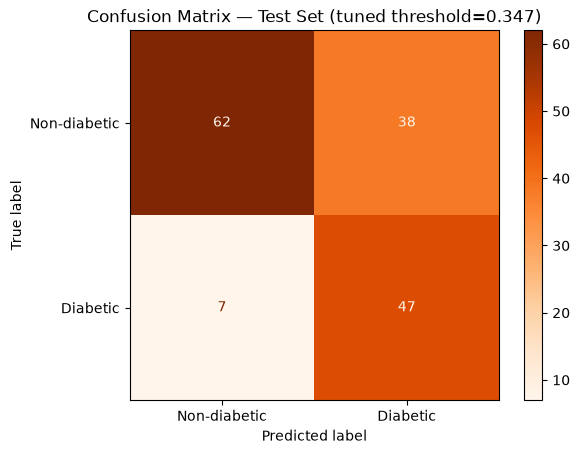

Tuned: TN=62  FP=38  FN=7  TP=47


In [28]:
tuned_thresh = 0.347  # from your OOF search above

y_test_pred_default = (y_test_proba >= 0.5).astype(int)
y_test_pred_tuned = (y_test_proba >= tuned_thresh).astype(int)

from sklearn.metrics import precision_score, recall_score, f1_score

comparison = pd.DataFrame({
    "default (0.5)": [
        precision_score(y_test, y_test_pred_default),
        recall_score(y_test, y_test_pred_default),
        f1_score(y_test, y_test_pred_default),
    ],
    f"tuned ({tuned_thresh})": [
        precision_score(y_test, y_test_pred_tuned),
        recall_score(y_test, y_test_pred_tuned),
        f1_score(y_test, y_test_pred_tuned),
    ],
}, index=["precision", "recall", "f1"])

print(comparison.round(3))

cm_tuned = confusion_matrix(y_test, y_test_pred_tuned)
ConfusionMatrixDisplay(cm_tuned, display_labels=["Non-diabetic", "Diabetic"]).plot(cmap="Oranges")
plt.title(f"Confusion Matrix — Test Set (tuned threshold={tuned_thresh})")
plt.show()

tn2, fp2, fn2, tp2 = cm_tuned.ravel()
print(f"Tuned: TN={tn2}  FP={fp2}  FN={fn2}  TP={tp2}")

Lowering the threshold from 0.5 to 0.347 cuts missed diabetic patients in half: false negatives drop from 14 to 7 (recall rises from 74% to 87%), at the cost of 12 additional false alarms (false positives rise from 26 to 38, precision drops from 61% to 55%). For a community health-worker screening tool, this is the right trade: a missed diabetic (FN) receives no further diagnostic opportunity and risks undetected complications, while a false alarm (FP) only costs an extra, low-stakes lab test to rule a healthy person out. Halving the number of missed diabetic patients — from 14 to 7 — is a meaningful real-world improvement that default-threshold accuracy alone would never have surfaced.